In [1]:
"""
predict.py — Single-Record Prediction (Standalone)
====================================================
Drop this file next to your param_store.json and run it.
No other pipeline files needed.

Requirements:
    pip install numpy

Usage — as a script:
    python predict.py                          # runs built-in examples
    python predict.py 1 0 0 1 0 0 1 0         # pass matches as CLI args

Usage — import into a notebook or script:
    from predict import load_model, predict, predict_df

    model = load_model("params/param_store.json")

    # Single record as a dict  (most readable)
    result = predict(model, {"S1":1, "S4":1, "S7":1})

    # Or as a plain list in source order
    result = predict(model, [1, 0, 0, 1, 0, 0, 1, 0])

    print(result["risk_score"])      # e.g. 0.6567
    print(result["tier"])            # e.g. "Moderate"
    print(result["primary_driver"])  # e.g. "S4"
    print(result["explanation"])     # human-readable sentence
"""

'\npredict.py — Single-Record Prediction (Standalone)\n====================================================\nDrop this file next to your param_store.json and run it.\nNo other pipeline files needed.\n\nRequirements:\n    pip install numpy\n\nUsage — as a script:\n    python predict.py                          # runs built-in examples\n    python predict.py 1 0 0 1 0 0 1 0         # pass matches as CLI args\n\nUsage — import into a notebook or script:\n    from predict import load_model, predict, predict_df\n\n    model = load_model("params/param_store.json")\n\n    # Single record as a dict  (most readable)\n    result = predict(model, {"S1":1, "S4":1, "S7":1})\n\n    # Or as a plain list in source order\n    result = predict(model, [1, 0, 0, 1, 0, 0, 1, 0])\n\n    print(result["risk_score"])      # e.g. 0.6567\n    print(result["tier"])            # e.g. "Moderate"\n    print(result["primary_driver"])  # e.g. "S4"\n    print(result["explanation"])     # human-readable sentence\n'

In [2]:
import json
import sys
import math
import numpy as np
from pathlib import Path
from typing import Union

In [3]:
# ---------------------------------------------------------------------------
# Model loader
# ---------------------------------------------------------------------------
def load_model(param_store_path: str = "params/param_store.json") -> dict:
    """
    Load the saved param store from disk.
    Returns a lightweight model dict ready for prediction.

    The model dict contains:
        source_order  — list of source names in column order
        p_means       — numpy array of posterior means (one per source)
        p_stds        — numpy array of posterior stds
        alphas        — numpy array of Beta alpha params
        betas         — numpy array of Beta beta params
        leak_mean     — float, baseline leak probability
        leak_alpha    — float
        leak_beta     — float
        version       — string, param store version
    """
    path = Path(param_store_path)
    if not path.exists():
        raise FileNotFoundError(
            f"Param store not found at: {path.resolve()}\n"
            "Run phase1_priors.py first to generate it."
        )

    with open(path) as f:
        store = json.load(f)

    source_order = store["source_order"]

    model = {
        "source_order": source_order,
        "p_means":  np.array([store["sources"][s]["mean"]  for s in source_order]),
        "p_stds":   np.array([store["sources"][s]["std"]   for s in source_order]),
        "alphas":   np.array([store["sources"][s]["alpha"] for s in source_order]),
        "betas":    np.array([store["sources"][s]["beta"]  for s in source_order]),
        "leak_mean":  store["leak"]["mean"],
        "leak_alpha": store["leak"]["alpha"],
        "leak_beta":  store["leak"]["beta"],
        "version":    store["version"],
    }
    return model

In [4]:
# ---------------------------------------------------------------------------
# Core prediction
# ---------------------------------------------------------------------------
def predict(
    model:        dict,
    matches:      Union[dict, list],
    n_mc:         int  = 2000,
    seed:         int  = 0,
) -> dict:
    """
    Score a single record and return a plain dict.

    Parameters
    ----------
    model : dict
        Output of load_model().
    matches : dict or list
        Which sources matched this record.

        As a dict  — keys are source names, values are 0 or 1.
            {"S1": 1, "S4": 1, "S7": 1}
            Unspecified sources default to 0 (no match).

        As a list  — values in the same order as model["source_order"].
            [1, 0, 0, 1, 0, 0, 1, 0]

    n_mc : int
        Monte Carlo samples for uncertainty. 2000 gives stable CIs.
        Use 500 for speed, 5000 for high-precision uncertainty.
    seed : int
        RNG seed. Same seed → identical output (useful for testing).

    Returns
    -------
    dict with keys:
        risk_score      float  — point estimate (uses posterior means)
        risk_p10        float  — 10th percentile over MC samples
        risk_p50        float  — median over MC samples
        risk_p90        float  — 90th percentile over MC samples
        ci_width        float  — risk_p90 - risk_p10 (uncertainty band)
        tier            str    — "Minimal" / "Low" / "Moderate" / "High"
        confidence      str    — "High" / "Moderate" / "Low" / "Very Low"
        primary_driver  str    — source with largest marginal impact
        matched         list   — source names that matched
        impacts         dict   — marginal impact per matched source
        explanation     str    — one-sentence human-readable summary
    """
    source_order = model["source_order"]
    n_sources    = len(source_order)

    # --- Normalise matches to a numpy array ---
    if isinstance(matches, dict):
        vec = np.array(
            [float(matches.get(s, 0)) for s in source_order],
            dtype=np.float64,
        )
    else:
        vec = np.asarray(matches, dtype=np.float64)
        if vec.shape[0] != n_sources:
            raise ValueError(
                f"matches has {vec.shape[0]} values but model has "
                f"{n_sources} sources ({source_order})"
            )

    if not np.all(np.isin(vec, [0.0, 1.0])):
        raise ValueError("matches values must all be 0 or 1")

    # --- Point estimate (deterministic, uses posterior means) ---
    log_one_minus_p = np.log1p(-model["p_means"])
    log_leak_fail   = math.log1p(-model["leak_mean"])
    log_fail_point  = log_leak_fail + float(vec @ log_one_minus_p)
    risk_point      = 1.0 - math.exp(log_fail_point)

    # --- Driver attribution ---
    impacts = {}
    for i, s in enumerate(source_order):
        if vec[i] == 1:
            log_fail_without = log_fail_point - log_one_minus_p[i]
            risk_without     = 1.0 - math.exp(log_fail_without)
            impacts[s]       = round(risk_point - risk_without, 6)

    primary_driver = max(impacts, key=impacts.get) if impacts else "Leak"

    # --- MC uncertainty (draw from Beta priors) ---
    rng          = np.random.default_rng(seed)
    p_i_mc       = rng.beta(model["alphas"], model["betas"], size=(n_mc, n_sources))
    p_leak_mc    = rng.beta(model["leak_alpha"], model["leak_beta"], size=n_mc)

    log_1mp_mc       = np.log1p(-p_i_mc)       # (n_mc, n_sources)
    source_log_fail  = log_1mp_mc @ vec         # (n_mc,)
    log_fail_mc      = np.log1p(-p_leak_mc) + source_log_fail
    risk_mc          = 1.0 - np.exp(log_fail_mc)

    risk_p10 = float(np.percentile(risk_mc, 10))
    risk_p50 = float(np.percentile(risk_mc, 50))
    risk_p90 = float(np.percentile(risk_mc, 90))
    ci_width = round(risk_p90 - risk_p10, 4)

    # --- Tier labels ---
    tier = (
        "High"     if risk_point >= 0.70 else
        "Moderate" if risk_point >= 0.40 else
        "Low"      if risk_point >= 0.15 else
        "Minimal"
    )
    confidence = (
        "High"      if ci_width < 0.05  else
        "Moderate"  if ci_width < 0.15  else
        "Low"       if ci_width < 0.40  else
        "Very Low"
    )

    matched = [s for s in source_order if vec[source_order.index(s)] == 1]

    # --- One-sentence explanation ---
    if not matched:
        explanation = (
            f"No sources matched; risk reflects baseline only "
            f"(score={risk_point:.3f}, {tier})."
        )
    else:
        top_impact = impacts[primary_driver]
        explanation = (
            f"{len(matched)} source(s) matched ({', '.join(matched)}); "
            f"risk score is {risk_point:.3f} ({tier}) with {confidence.lower()} confidence "
            f"[80% CI: {risk_p10:.3f}–{risk_p90:.3f}]. "
            f"Primary driver: {primary_driver} "
            f"(contributes {top_impact:.3f} of the total score)."
        )

    return {
        "risk_score":     round(risk_point, 4),
        "risk_p10":       round(risk_p10, 4),
        "risk_p50":       round(risk_p50, 4),
        "risk_p90":       round(risk_p90, 4),
        "ci_width":       ci_width,
        "tier":           tier,
        "confidence":     confidence,
        "primary_driver": primary_driver,
        "matched":        matched,
        "impacts":        impacts,
        "explanation":    explanation,
    }


In [5]:
# ---------------------------------------------------------------------------
# Convenience: score a list of records → list of dicts (no pandas needed)
# ---------------------------------------------------------------------------
def predict_many(
    model:   dict,
    records: list[Union[dict, list]],
    n_mc:    int = 1000,
    seed:    int = 0,
) -> list[dict]:
    """
    Score multiple records. Returns a list of result dicts.
    Suitable for use in a notebook where you want to loop or inspect results.

    For large files (1000+ records) use phase5_batch.py instead —
    it uses fully vectorised NumPy and is much faster at scale.
    """
    return [predict(model, r, n_mc=n_mc, seed=seed) for r in records]


# ---------------------------------------------------------------------------
# Convenience: score records → pandas DataFrame (if pandas is available)
# ---------------------------------------------------------------------------
def predict_df(
    model:   dict,
    records: list[Union[dict, list]],
    n_mc:    int = 1000,
    seed:    int = 0,
):
    """
    Score multiple records and return a pandas DataFrame.
    Requires pandas (pip install pandas).
    """
    try:
        import pandas as pd
    except ImportError:
        raise ImportError("pandas is required for predict_df. pip install pandas")

    results = predict_many(model, records, n_mc=n_mc, seed=seed)
    return pd.DataFrame(results)


# ---------------------------------------------------------------------------
# Pretty printer
# ---------------------------------------------------------------------------
def print_result(result: dict, label: str = "") -> None:
    """Print a single prediction result in a readable format."""
    header = f"  [{label}]" if label else "  Result"
    print(header)
    print(f"    risk_score    : {result['risk_score']:.4f}  ({result['tier']})")
    print(f"    80% CI        : [{result['risk_p10']:.4f}, {result['risk_p90']:.4f}]"
          f"  width={result['ci_width']:.4f}  ({result['confidence']} confidence)")
    print(f"    primary driver: {result['primary_driver']}")
    print(f"    matched       : {result['matched'] or 'none'}")
    if result["impacts"]:
        print(f"    contributions :")
        for src, imp in sorted(result["impacts"].items(), key=lambda x: -x[1]):
            bar = "█" * max(1, int(imp * 80))
            print(f"      {src}: {imp:.4f}  {bar}")
    print(f"    explanation   : {result['explanation']}")
    print()

In [6]:
# --- Load model ---
MODEL_PATH = "params/param_store.json"
print(f"\nLoading model from: {MODEL_PATH}")
model = load_model(MODEL_PATH)
print(f"Model version : {model['version']}")
print(f"Sources       : {model['source_order']}")
print(f"Leak baseline : {model['leak_mean']:.4f}\n")


Loading model from: params/param_store.json
Model version : 20260221_175538
Sources       : ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8']
Leak baseline : 0.0200



In [7]:
import pandas as pd
sample_records = [
    {"S1": 1, "S4": 1},
    {"S7": 1, "S6": 1},
    {"S3": 1, "S5": 1},
    {},
]
df = predict_df(model, sample_records, n_mc=1000, seed=0)
print("  predict_df output:")
print(df[["risk_score", "risk_p10", "risk_p90",
           "tier", "confidence", "primary_driver"]].to_string(index=False))
print()

  predict_df output:
 risk_score  risk_p10  risk_p90     tier confidence primary_driver
     0.8603    0.8301    0.8920     High   Moderate             S4
     0.9608    0.9470    0.9727     High       High             S7
     0.6497    0.5870    0.7091 Moderate   Moderate             S5
     0.0200    0.0055    0.0369  Minimal       High           Leak



In [8]:
predict_many(model, sample_records, n_mc=1000, seed=0)[0]

{'risk_score': 0.8603,
 'risk_p10': 0.8301,
 'risk_p50': 0.8627,
 'risk_p90': 0.892,
 'ci_width': 0.0619,
 'tier': 'High',
 'confidence': 'Moderate',
 'primary_driver': 'S4',
 'matched': ['S1', 'S4'],
 'impacts': {'S1': 0.00735, 'S4': 0.79135},
 'explanation': '2 source(s) matched (S1, S4); risk score is 0.860 (High) with moderate confidence [80% CI: 0.830–0.892]. Primary driver: S4 (contributes 0.791 of the total score).'}

In [9]:
# ---------------------------------------------------------------------------
# Main — run examples or score from CLI args
# ---------------------------------------------------------------------------
if __name__ == "__main__":

    # --- Load model ---
    MODEL_PATH = "params/param_store.json"
    print(f"\nLoading model from: {MODEL_PATH}")
    model = load_model(MODEL_PATH)
    print(f"Model version : {model['version']}")
    print(f"Sources       : {model['source_order']}")
    print(f"Leak baseline : {model['leak_mean']:.4f}\n")

    # --- CLI mode: python predict.py 1 0 0 1 0 0 1 0 ---
    if len(sys.argv) > 1:
        try:
            cli_matches = [int(x) for x in sys.argv[1:]]
        except ValueError:
            print("Usage: python predict.py 1 0 0 1 0 0 1 0")
            print("       (one 0/1 value per source, in source order)")
            sys.exit(1)

        result = predict(model, cli_matches, n_mc=2000)
        print_result(result, label="CLI input: " + " ".join(sys.argv[1:]))
        sys.exit(0)

    # --- Built-in examples ---
    print("=" * 55)
    print("  Built-in Prediction Examples")
    print("=" * 55)

    examples = [
        # (matches, label)
        ({"S1": 1, "S4": 1, "S7": 1},            "Dict input: S1+S4+S7"),
        ([1, 0, 0, 1, 0, 0, 1, 0],               "List input: S1+S4+S7"),
        ({},                                       "No matches (baseline)"),
        ({"S7": 1},                                "S7 only (high-confidence source)"),
        ({"S4": 1},                                "S4 only (low-confidence source)"),
        ({"S1":1,"S2":1,"S3":1,"S4":1,
          "S5":1,"S6":1,"S7":1,"S8":1},           "All sources matched"),
    ]

    for matches, label in examples:
        result = predict(model, matches, n_mc=2000, seed=0)
        print_result(result, label=label)

    # --- Notebook-style usage demo ---
    print("=" * 55)
    print("  Notebook Usage Demo")
    print("=" * 55)
    print("""
  # In a Jupyter notebook:

  from predict import load_model, predict, predict_df

  model = load_model("params/param_store.json")

  # Score one record as a dict (clearest intent)
  r = predict(model, {"S1": 1, "S4": 1, "S7": 1})
  print(r["risk_score"])      # 0.6567
  print(r["tier"])            # Moderate
  print(r["explanation"])     # 3 source(s) matched ...

  # Access specific fields
  print(r["risk_p10"], r["risk_p90"])   # 80% CI bounds
  print(r["impacts"])                   # per-source contributions

  # Score several records at once → DataFrame
  records = [
      {"S1": 1, "S4": 1},
      {"S7": 1, "S6": 1},
      {},
  ]
  df = predict_df(model, records)
  print(df[["risk_score", "tier", "primary_driver"]])
""")

    # --- Show predict_df output if pandas is available ---
    try:
        import pandas as pd
        sample_records = [
            {"S1": 1, "S4": 1},
            {"S7": 1, "S6": 1},
            {"S3": 1, "S5": 1},
            {},
        ]
        df = predict_df(model, sample_records, n_mc=1000, seed=0)
        print("  predict_df output:")
        print(df[["risk_score", "risk_p10", "risk_p90",
                   "tier", "confidence", "primary_driver"]].to_string(index=False))
        print()
    except ImportError:
        print("  (pandas not installed — predict_df not shown)")



Loading model from: params/param_store.json
Model version : 20260221_175538
Sources       : ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8']
Leak baseline : 0.0200

Usage: python predict.py 1 0 0 1 0 0 1 0
       (one 0/1 value per source, in source order)


SystemExit: 1

/Users/mattdube/mambaforge/envs/pymc_env/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [10]:
from predict import load_model, predict, predict_df

model = load_model("params/param_store.json")

# Score one record as a dict (clearest intent)
r = predict(model, {"S1": 1, "S4": 1, "S7": 1})
print(r["risk_score"])      # 0.6567
print(r["tier"])            # Moderate
print(r["explanation"])     # 3 source(s) matched ...

# Access specific fields
print(r["risk_p10"], r["risk_p90"])   # 80% CI bounds
print(r["impacts"])                   # per-source contributions

0.993
High
3 source(s) matched (S1, S4, S7); risk score is 0.993 (High) with high confidence [80% CI: 0.990–0.996]. Primary driver: S7 (contributes 0.133 of the total score).
0.9904 0.9955
{'S1': 0.000367, 'S4': 0.039568, 'S7': 0.132668}


In [11]:
# Score several records at once → DataFrame
records = [
  {"S1": 1, "S4": 1},
  {"S7": 1, "S6": 1},
  {},
]
df = predict_df(model, records)
print(df[["risk_score", "tier", "primary_driver"]])

   risk_score     tier primary_driver
0      0.8603     High             S4
1      0.9608     High             S7
2      0.0200  Minimal           Leak


Generating matplotlib/seaborn visualizations...
[matplotlib] Saved → source_distributions_grid.png


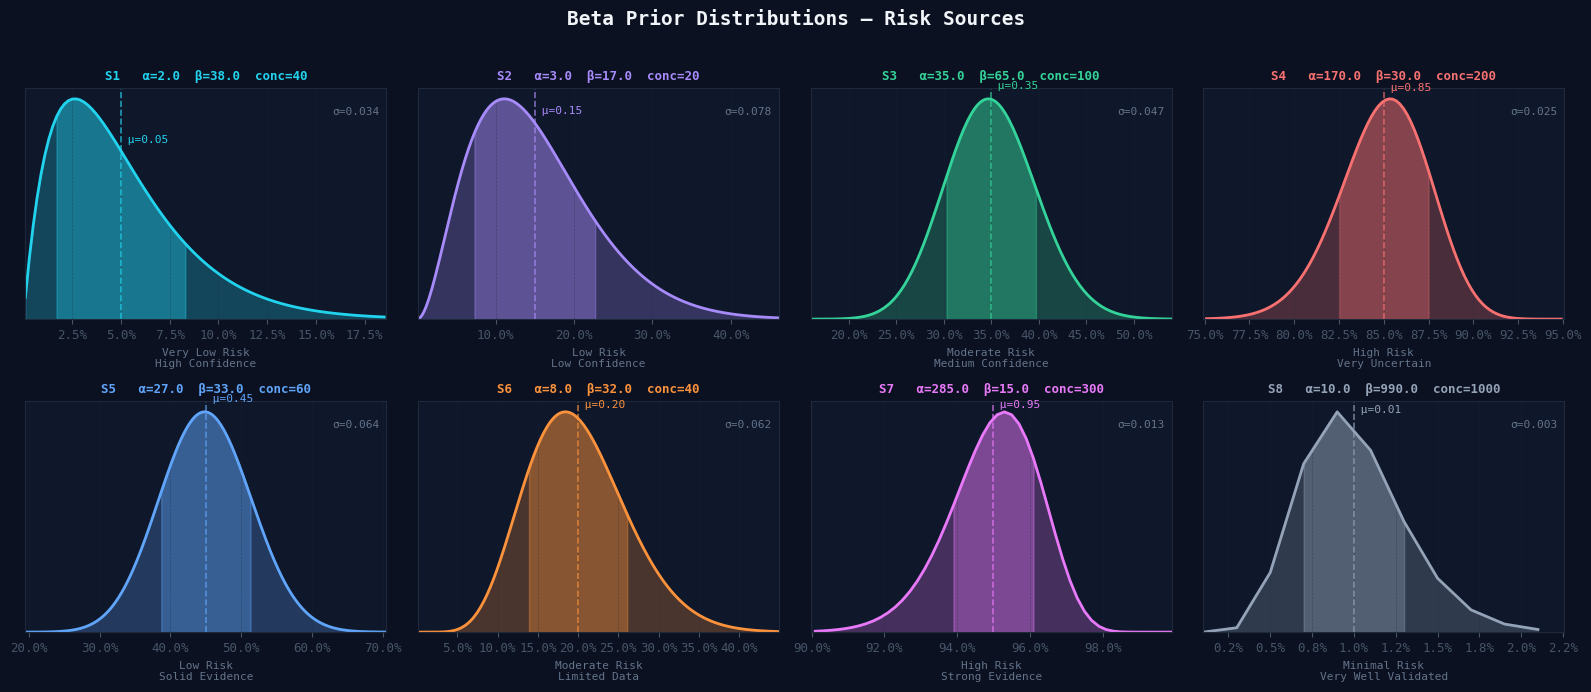

[matplotlib] Saved → source_distributions_overlay.png


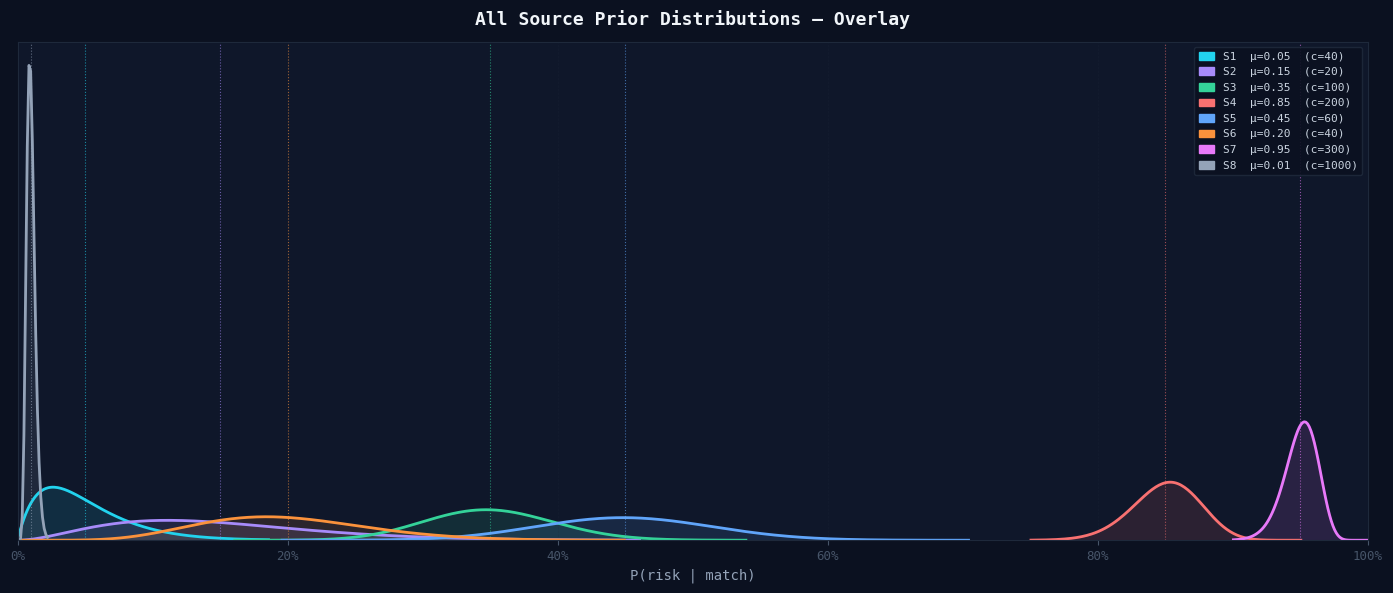

[matplotlib] Saved → source_distributions_summary.png


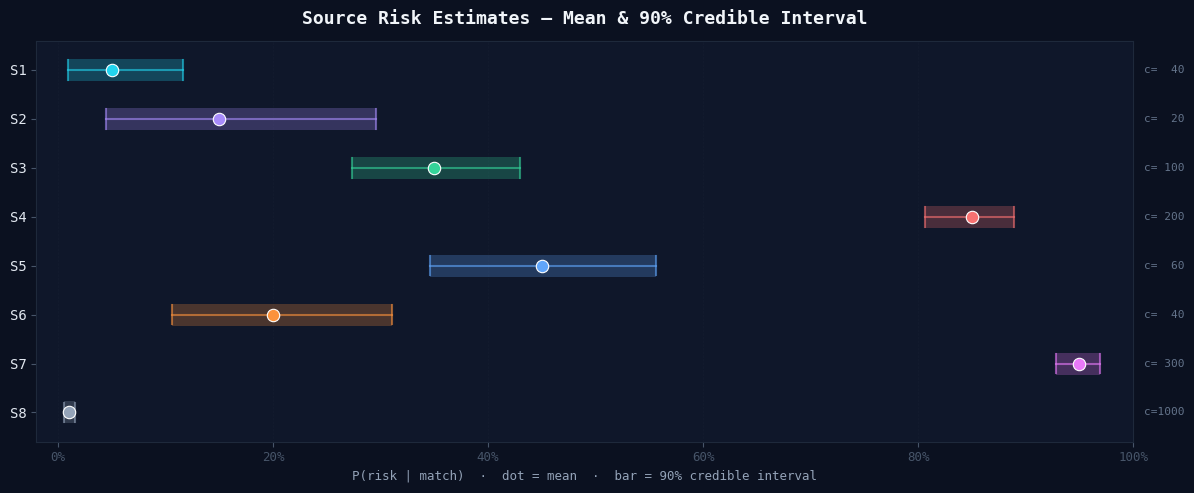


Done. Three plots saved to current directory.


In [12]:
"""
visualize_distributions_matplotlib.py
======================================
Visualizes the Beta prior distributions for all risk sources
using matplotlib and seaborn.

Requires:
    pip install matplotlib seaborn scipy numpy

Run:
    python visualize_distributions_matplotlib.py

Outputs:
    source_distributions.png  — saved to current directory
    (also displays interactively if a display is available)
"""

import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
from scipy.stats import beta as beta_dist
import seaborn as sns

# ── Load param store ──────────────────────────────────────────────────────────
PARAM_PATH = "params/param_store.json"

with open(PARAM_PATH) as f:
    store = json.load(f)

SOURCE_ORDER = store["source_order"]
SOURCES      = store["sources"]
LEAK         = store["leak"]

# ── Palette (consistent with the React visualizer) ────────────────────────────
COLORS = {
    "S1": "#22d3ee", "S2": "#a78bfa", "S3": "#34d399", "S4": "#f87171",
    "S5": "#60a5fa", "S6": "#fb923c", "S7": "#e879f9", "S8": "#94a3b8",
}

# ── Annotation labels ─────────────────────────────────────────────────────────
LABELS = {
    "S1": "Very Low Risk\nHigh Confidence",
    "S2": "Low Risk\nLow Confidence",
    "S3": "Moderate Risk\nMedium Confidence",
    "S4": "High Risk\nVery Uncertain",
    "S5": "Low Risk\nSolid Evidence",
    "S6": "Moderate Risk\nLimited Data",
    "S7": "High Risk\nStrong Evidence",
    "S8": "Minimal Risk\nVery Well Validated",
}

# ── Style setup ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor":  "#0b1120",
    "axes.facecolor":    "#0f172a",
    "axes.edgecolor":    "#1e293b",
    "axes.labelcolor":   "#94a3b8",
    "xtick.color":       "#475569",
    "ytick.color":       "#475569",
    "text.color":        "#e2e8f0",
    "grid.color":        "#1e293b",
    "grid.linestyle":    "--",
    "grid.linewidth":    0.5,
    "font.family":       "monospace",
    "font.size":         9,
})

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 1 — Small-multiple grid (one panel per source)
# ─────────────────────────────────────────────────────────────────────────────
def plot_small_multiples(save_path="source_distributions_grid.png"):
    fig, axes = plt.subplots(2, 4, figsize=(16, 7))
    fig.patch.set_facecolor("#0b1120")
    fig.suptitle(
        "Beta Prior Distributions — Risk Sources",
        fontsize=14, fontweight="bold", color="#f1f5f9",
        y=0.98, fontfamily="monospace",
    )

    x = np.linspace(0.001, 0.999, 500)

    for ax, src in zip(axes.flatten(), SOURCE_ORDER):
        s     = SOURCES[src]
        a, b  = s["alpha"], s["beta"]
        mean  = s["mean"]
        std   = s["std"]
        color = COLORS[src]
        conc  = s["expert_concentration"]

        y = beta_dist.pdf(x, a, b)

        # Adaptive x-range: show ±4 std around mean
        lo = max(0.001, mean - 4 * std)
        hi = min(0.999, mean + 4 * std)
        mask = (x >= lo) & (x <= hi)

        ax.set_facecolor("#0f172a")
        ax.fill_between(x[mask], y[mask], alpha=0.25, color=color)
        ax.plot(x[mask], y[mask], color=color, linewidth=2)

        # Mean line
        mean_y = beta_dist.pdf(mean, a, b)
        ax.axvline(mean, color=color, linewidth=1.2, linestyle="--", alpha=0.7)
        ax.text(mean, mean_y * 1.04, f" μ={mean:.2f}",
                color=color, fontsize=8, va="bottom", ha="left")

        # ±1 std shading
        lo_std = max(0.001, mean - std)
        hi_std = min(0.999, mean + std)
        mask_std = (x >= lo_std) & (x <= hi_std)
        ax.fill_between(x[mask_std], y[mask_std], alpha=0.35, color=color)

        # Axes
        ax.set_xlim(lo, hi)
        ax.set_ylim(0, None)
        ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.1%}"))
        ax.set_yticks([])
        ax.grid(True, axis="x", alpha=0.4)

        # Title block
        ax.set_title(
            f"{src}   α={a:.1f}  β={b:.1f}  conc={conc}",
            color=color, fontsize=9, fontweight="bold", pad=6,
        )
        ax.set_xlabel(LABELS[src], color="#64748b", fontsize=8, labelpad=4)

        # std annotation
        ax.annotate(
            f"σ={std:.3f}", xy=(0.98, 0.92), xycoords="axes fraction",
            ha="right", va="top", fontsize=8, color="#64748b",
        )

        for spine in ax.spines.values():
            spine.set_edgecolor("#1e293b")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor="#0b1120")
    print(f"[matplotlib] Saved → {save_path}")
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 2 — Overlay comparison (all sources on one axes)
# ─────────────────────────────────────────────────────────────────────────────
def plot_overlay(save_path="source_distributions_overlay.png"):
    fig, ax = plt.subplots(figsize=(14, 6))
    fig.patch.set_facecolor("#0b1120")
    ax.set_facecolor("#0f172a")

    x = np.linspace(0.001, 0.999, 800)

    for src in SOURCE_ORDER:
        s     = SOURCES[src]
        a, b  = s["alpha"], s["beta"]
        mean  = s["mean"]
        std   = s["std"]
        color = COLORS[src]

        # Zoom window per source
        lo = max(0.001, mean - 4 * std)
        hi = min(0.999, mean + 4 * std)
        mask = (x >= lo) & (x <= hi)

        y = beta_dist.pdf(x, a, b)

        ax.fill_between(x[mask], y[mask], alpha=0.12, color=color)
        ax.plot(x[mask], y[mask], color=color, linewidth=2, label=src)
        ax.axvline(mean, color=color, linewidth=0.8, linestyle=":", alpha=0.6)

    ax.set_xlim(0, 1)
    ax.set_ylim(0)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.set_yticks([])
    ax.set_xlabel("P(risk | match)", color="#94a3b8", fontsize=10)
    ax.set_title(
        "All Source Prior Distributions — Overlay",
        color="#f1f5f9", fontsize=13, fontweight="bold", pad=12, fontfamily="monospace",
    )
    ax.grid(True, axis="x", alpha=0.3)

    for spine in ax.spines.values():
        spine.set_edgecolor("#1e293b")

    # Custom legend with mean values
    handles = [
        mpatches.Patch(color=COLORS[s], label=f"{s}  μ={SOURCES[s]['mean']:.2f}  (c={SOURCES[s]['expert_concentration']})")
        for s in SOURCE_ORDER
    ]
    ax.legend(
        handles=handles, loc="upper right", fontsize=8,
        facecolor="#0b1120", edgecolor="#1e293b", labelcolor="#cbd5e1",
        framealpha=0.9, handlelength=1.4,
    )

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor="#0b1120")
    print(f"[matplotlib] Saved → {save_path}")
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 3 — Summary comparison: mean ± CI strip chart
# ─────────────────────────────────────────────────────────────────────────────
def plot_summary_strip(save_path="source_distributions_summary.png"):
    fig, ax = plt.subplots(figsize=(12, 5))
    fig.patch.set_facecolor("#0b1120")
    ax.set_facecolor("#0f172a")

    # Compute 90% credible intervals from the Beta
    ci_lo = np.array([beta_dist.ppf(0.05, SOURCES[s]["alpha"], SOURCES[s]["beta"]) for s in SOURCE_ORDER])
    ci_hi = np.array([beta_dist.ppf(0.95, SOURCES[s]["alpha"], SOURCES[s]["beta"]) for s in SOURCE_ORDER])
    means = np.array([SOURCES[s]["mean"] for s in SOURCE_ORDER])
    concs = np.array([SOURCES[s]["expert_concentration"] for s in SOURCE_ORDER])

    y_pos = np.arange(len(SOURCE_ORDER))

    for i, src in enumerate(SOURCE_ORDER):
        color = COLORS[src]
        lo, hi, m = ci_lo[i], ci_hi[i], means[i]

        # CI bar
        ax.barh(i, hi - lo, left=lo, height=0.45,
                color=color, alpha=0.25, zorder=2)
        # CI whiskers
        ax.plot([lo, hi], [i, i], color=color, linewidth=1.5, alpha=0.6, zorder=3)
        ax.plot([lo, lo], [i - 0.2, i + 0.2], color=color, linewidth=1.5, alpha=0.6, zorder=3)
        ax.plot([hi, hi], [i - 0.2, i + 0.2], color=color, linewidth=1.5, alpha=0.6, zorder=3)
        # Mean dot
        ax.scatter(m, i, color=color, s=80, zorder=5, edgecolors="white", linewidths=0.8)

        # Concentration indicator (dot size legend note)
        ax.text(1.01, i, f"c={concs[i]:>4.0f}", va="center",
                fontsize=8, color="#64748b", transform=ax.get_yaxis_transform())

    ax.set_yticks(y_pos)
    ax.set_yticklabels(SOURCE_ORDER, fontsize=10, color="#e2e8f0")
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.set_xlabel("P(risk | match)  ·  dot = mean  ·  bar = 90% credible interval",
                  color="#94a3b8", fontsize=9)
    ax.set_title(
        "Source Risk Estimates — Mean & 90% Credible Interval",
        color="#f1f5f9", fontsize=13, fontweight="bold", pad=12, fontfamily="monospace",
    )
    ax.set_xlim(-0.02, 1.0)
    ax.grid(True, axis="x", alpha=0.3)
    ax.invert_yaxis()

    for spine in ax.spines.values():
        spine.set_edgecolor("#1e293b")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor="#0b1120")
    print(f"[matplotlib] Saved → {save_path}")
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# Run all three
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("Generating matplotlib/seaborn visualizations...")
    plot_small_multiples()
    plot_overlay()
    plot_summary_strip()
    print("\nDone. Three plots saved to current directory.")

In [13]:
"""
visualize_distributions_altair.py
===================================
Visualizes the Beta prior distributions for all risk sources
using Altair 5. Produces three interactive HTML files.

Requires:
    pip install altair numpy scipy

Run:
    python visualize_distributions_altair.py

Outputs:
    source_distributions_grid.html    — small-multiple panel per source
    source_distributions_overlay.html — all sources overlaid, click legend to isolate
    source_distributions_summary.html — mean + 90% CI strip chart
"""

import json
import numpy as np
from scipy.stats import beta as beta_dist

try:
    import altair as alt
except ImportError:
    raise ImportError("Altair is not installed. Run: pip install altair")

# ── Load param store ──────────────────────────────────────────────────────────
PARAM_PATH = "params/param_store.json"

with open(PARAM_PATH) as f:
    store = json.load(f)

SOURCE_ORDER = store["source_order"]
SOURCES      = store["sources"]

# ── Palette ───────────────────────────────────────────────────────────────────
COLORS = {
    "S1": "#22d3ee", "S2": "#a78bfa", "S3": "#34d399", "S4": "#f87171",
    "S5": "#60a5fa", "S6": "#fb923c", "S7": "#e879f9", "S8": "#94a3b8",
}

LABELS = {
    "S1": "Very Low Risk · High Confidence",
    "S2": "Low Risk · Low Confidence",
    "S3": "Moderate Risk · Medium Confidence",
    "S4": "High Risk · Very Uncertain",
    "S5": "Low Risk · Solid Evidence",
    "S6": "Moderate Risk · Limited Data",
    "S7": "High Risk · Strong Evidence",
    "S8": "Minimal Risk · Very Well Validated",
}

N_POINTS = 300

# ── Dark theme — applied via .configure() ─────────────────────────────────────
# Only uses properties that exist in Altair 5's schema.
DARK_CONFIG = {
    "background": "#0b1120",
    "view": {
        "fill":   "#0f172a",
        "stroke": "#1e293b",
    },
    "axis": {
        "domainColor":   "#1e293b",
        "gridColor":     "#1e293b",
        "gridDash":      [3, 3],
        "labelColor":    "#64748b",
        "labelFontSize": 10,
        "tickColor":     "#1e293b",
        "titleColor":    "#94a3b8",
        "titleFontSize": 11,
    },
    "title": {
        "color":      "#f1f5f9",
        "fontSize":   14,
        "fontWeight": "bold",
        "anchor":     "start",
        "offset":     10,
    },
    "legend": {
        "labelColor":    "#cbd5e1",
        "labelFontSize": 10,
        "titleColor":    "#94a3b8",
        "titleFontSize": 10,
        "symbolSize":    120,
        "padding":       10,
    },
    "header": {
        "labelColor":    "#94a3b8",
        "labelFontSize": 12,
        "labelFontWeight": "bold",
    },
}


# ── Data builders ─────────────────────────────────────────────────────────────
def build_pdf_rows():
    """Long-format rows with Beta PDF values. Mean is embedded per row."""
    rows = []
    for src in SOURCE_ORDER:
        s    = SOURCES[src]
        a, b = s["alpha"], s["beta"]
        mean = s["mean"]
        std  = s["std"]
        conc = s["expert_concentration"]
        lo   = max(0.001, mean - 4 * std)
        hi   = min(0.999, mean + 4 * std)
        xs   = np.linspace(lo, hi, N_POINTS)
        ys   = beta_dist.pdf(xs, a, b)
        for x, y in zip(xs, ys):
            rows.append({
                "source":        src,
                "x":             round(float(x), 6),
                "pdf":           round(float(y), 6),
                "mean":          mean,
                "std":           std,
                "alpha":         a,
                "beta":          b,
                "concentration": conc,
                "label":         LABELS[src],
            })
    return rows


def build_summary_rows():
    """One row per source: mean + 90% credible interval."""
    rows = []
    for src in SOURCE_ORDER:
        s     = SOURCES[src]
        a, b  = s["alpha"], s["beta"]
        ci_lo = float(beta_dist.ppf(0.05, a, b))
        ci_hi = float(beta_dist.ppf(0.95, a, b))
        rows.append({
            "source":        src,
            "mean":          s["mean"],
            "std":           s["std"],
            "ci_lo":         round(ci_lo, 5),
            "ci_hi":         round(ci_hi, 5),
            "concentration": s["expert_concentration"],
            "label":         LABELS[src],
        })
    return rows


def color_scale():
    return alt.Scale(
        domain=SOURCE_ORDER,
        range=[COLORS[s] for s in SOURCE_ORDER],
    )


# ─────────────────────────────────────────────────────────────────────────────
# CHART 1 — Small-multiple grid
# ─────────────────────────────────────────────────────────────────────────────
def chart_small_multiples(save_path="source_distributions_grid.html"):
    """
    One panel per source. All three layers (area, line, mean rule) share the
    same alt.Data object — required by Altair 5 for faceted layer charts.
    Mean is a column in the PDF data so no second dataset is needed.
    """
    data = alt.Data(values=build_pdf_rows())

    color_enc = alt.Color("source:N", scale=color_scale(), legend=None)

    tooltips = [
        alt.Tooltip("source:N",        title="Source"),
        alt.Tooltip("x:Q",             title="P(risk)",      format=".3f"),
        alt.Tooltip("pdf:Q",           title="Density",      format=".2f"),
        alt.Tooltip("mean:Q",          title="Mean",         format=".3f"),
        alt.Tooltip("std:Q",           title="Std",          format=".3f"),
        alt.Tooltip("concentration:Q", title="Concentration"),
        alt.Tooltip("label:N",         title="Description"),
    ]

    x_enc = alt.X("x:Q", axis=alt.Axis(format=".0%", title="P(risk | match)"))
    y_enc = alt.Y("pdf:Q", axis=alt.Axis(title="", labels=False, ticks=False, grid=False))

    area = (
        alt.Chart(data)
        .mark_area(opacity=0.18, interpolate="monotone")
        .encode(x=x_enc, y=y_enc, color=color_enc, tooltip=tooltips)
    )

    line = (
        alt.Chart(data)
        .mark_line(opacity=0.9, strokeWidth=2, interpolate="monotone")
        .encode(x=x_enc, y=y_enc, color=color_enc, tooltip=tooltips)
    )

    # Rule uses `mean` column already in every row — same data source, no mixing.
    mean_rule = (
        alt.Chart(data)
        .mark_rule(strokeDash=[4, 3], opacity=0.6, strokeWidth=1.2)
        .encode(x=alt.X("mean:Q"), color=color_enc)
    )

    chart = (
        alt.layer(area, line, mean_rule)
        .properties(width=220, height=150)
        .facet(
            facet=alt.Facet("source:N", sort=SOURCE_ORDER),
            columns=4,
        )
        .properties(title="Beta Prior Distributions — Risk Sources")
        .configure(**DARK_CONFIG)
        .configure_facet(spacing=14)
    )

    chart.save(save_path)
    print(f"[altair] Saved → {save_path}")
    return chart


# ─────────────────────────────────────────────────────────────────────────────
# CHART 2 — Overlay
# ─────────────────────────────────────────────────────────────────────────────
def chart_overlay(save_path="source_distributions_overlay.html"):
    """
    All sources on one chart. Click legend to isolate a source.
    Mean rules use the same dataset as curves (mean column embedded per row).
    """
    data = alt.Data(values=build_pdf_rows())

    selection = alt.selection_point(fields=["source"], bind="legend")

    color_enc = alt.Color(
        "source:N",
        scale=color_scale(),
        legend=alt.Legend(title="Source  (click to isolate)", symbolStrokeWidth=3),
    )

    x_enc = alt.X(
        "x:Q",
        scale=alt.Scale(domain=[0, 1]),
        axis=alt.Axis(format=".0%", title="P(risk | match)", tickCount=6),
    )
    y_enc = alt.Y("pdf:Q", axis=alt.Axis(title="Density", labels=False, ticks=False))

    tooltips = [
        alt.Tooltip("source:N",        title="Source"),
        alt.Tooltip("x:Q",             title="P(risk)",      format=".3f"),
        alt.Tooltip("pdf:Q",           title="Density",      format=".2f"),
        alt.Tooltip("mean:Q",          title="Mean",         format=".3f"),
        alt.Tooltip("std:Q",           title="Std",          format=".3f"),
        alt.Tooltip("concentration:Q", title="Concentration"),
        alt.Tooltip("label:N",         title="Description"),
    ]

    line = (
        alt.Chart(data)
        .mark_line(strokeWidth=2.2, interpolate="monotone")
        .encode(
            x=x_enc, y=y_enc, color=color_enc,
            opacity=alt.condition(selection, alt.value(0.9), alt.value(0.08)),
            tooltip=tooltips,
        )
        .add_params(selection)
    )

    area = (
        alt.Chart(data)
        .mark_area(opacity=0.12, interpolate="monotone")
        .encode(
            x=x_enc, y=y_enc, color=color_enc,
            opacity=alt.condition(selection, alt.value(0.15), alt.value(0.04)),
        )
        .add_params(selection)
    )

    mean_rule = (
        alt.Chart(data)
        .mark_rule(strokeDash=[3, 4], strokeWidth=1.1)
        .encode(
            x=alt.X("mean:Q"),
            color=color_enc,
            opacity=alt.condition(selection, alt.value(0.6), alt.value(0.06)),
        )
        .add_params(selection)
    )

    chart = (
        alt.layer(area, line, mean_rule)
        .properties(
            width=760,
            height=360,
            title="All Source Prior Distributions — Overlay",
        )
        .configure(**DARK_CONFIG)
    )

    chart.save(save_path)
    print(f"[altair] Saved → {save_path}")
    return chart


# ─────────────────────────────────────────────────────────────────────────────
# CHART 3 — Summary strip (mean + 90% CI)
# ─────────────────────────────────────────────────────────────────────────────
def chart_summary_strip(save_path="source_distributions_summary.html"):
    """Mean dot + 90% CI bar per source, sorted by source order."""
    data = alt.Data(values=build_summary_rows())

    x_scale = alt.Scale(domain=[-0.02, 1.05])
    x_fmt   = alt.Axis(format=".0%", title="P(risk | match)")
    y_sort  = alt.Y("source:N", sort=SOURCE_ORDER, axis=alt.Axis(title="", labelFontSize=12))

    def color_for(field="source:N"):
        return alt.Color(field, scale=color_scale(), legend=None)

    tooltips = [
        alt.Tooltip("source:N",        title="Source"),
        alt.Tooltip("mean:Q",          title="Mean",      format=".3f"),
        alt.Tooltip("std:Q",           title="Std",       format=".3f"),
        alt.Tooltip("ci_lo:Q",         title="CI 90% lo", format=".3f"),
        alt.Tooltip("ci_hi:Q",         title="CI 90% hi", format=".3f"),
        alt.Tooltip("concentration:Q", title="Concentration"),
        alt.Tooltip("label:N",         title="Description"),
    ]

    # CI bar (x = lo, x2 = hi)
    ci_bar = (
        alt.Chart(data)
        .mark_bar(opacity=0.28)
        .encode(
            x=alt.X("ci_lo:Q", scale=x_scale, axis=x_fmt),
            x2=alt.X2("ci_hi:Q"),
            y=y_sort,
            color=color_for(),
            tooltip=tooltips,
        )
    )

    # CI end caps (tick marks)
    ci_lo_tick = (
        alt.Chart(data)
        .mark_tick(thickness=2, size=14, opacity=0.7)
        .encode(
            x=alt.X("ci_lo:Q", scale=x_scale),
            y=alt.Y("source:N", sort=SOURCE_ORDER),
            color=color_for(),
        )
    )

    ci_hi_tick = (
        alt.Chart(data)
        .mark_tick(thickness=2, size=14, opacity=0.7)
        .encode(
            x=alt.X("ci_hi:Q", scale=x_scale),
            y=alt.Y("source:N", sort=SOURCE_ORDER),
            color=color_for(),
        )
    )

    # Mean dot
    mean_dot = (
        alt.Chart(data)
        .mark_point(size=120, filled=True, stroke="white", strokeWidth=1.0)
        .encode(
            x=alt.X("mean:Q", scale=x_scale),
            y=alt.Y("source:N", sort=SOURCE_ORDER),
            color=color_for(),
            tooltip=tooltips,
        )
    )

    # Concentration label to the right of each CI bar
    conc_text = (
        alt.Chart(data)
        .mark_text(align="left", dx=6, fontSize=9, opacity=0.6)
        .encode(
            x=alt.X("ci_hi:Q", scale=x_scale),
            y=alt.Y("source:N", sort=SOURCE_ORDER),
            text=alt.Text("concentration:Q", format=".0f"),
            color=alt.value("#64748b"),
        )
    )

    chart = (
        alt.layer(ci_bar, ci_lo_tick, ci_hi_tick, mean_dot, conc_text)
        .properties(
            width=640,
            height=280,
            title="Source Risk Estimates — Mean & 90% Credible Interval",
        )
        .configure(**DARK_CONFIG)
    )

    chart.save(save_path)
    print(f"[altair] Saved → {save_path}")
    return chart


# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("Generating Altair 5 visualizations...")
    chart_small_multiples()
    chart_overlay()
    chart_summary_strip()
    print("\nDone. Open the .html files in any browser.")

Generating Altair 5 visualizations...
[altair] Saved → source_distributions_grid.html
[altair] Saved → source_distributions_overlay.html
[altair] Saved → source_distributions_summary.html

Done. Open the .html files in any browser.
